In [16]:
# import thư viện 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

In [17]:
# Load dataset
df = pd.read_csv('data.csv', sep=';')

print(f"Shape: {df.shape}")
print(f"\nPhân bố nhãn Target:")
print(df['Target'].value_counts())
print(f"\nKiểm tra missing values: {df.isnull().sum().sum()} giá trị bị thiếu")

Shape: (4424, 37)

Phân bố nhãn Target:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Kiểm tra missing values: 0 giá trị bị thiếu


### Assignment 1 (4 scores):

- Use Numpy only to construct the Logistic Regression model.
- Train that Logistic Regression model dataset using the Gradient Descent approach on the [Predict students’ dropout and academic success](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success) dataset. *Note that three class in this dataset must be merge into two class as: graduate and non-graduate (dropout or enroll)*.
- Evaluate that Logistic Regression model on the [Predict students’ dropout and academic success](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success) dataset.
- Visualize the loss function of the training process.

Theo yêu cầu đề bài, 3 nhãn ban đầu được **gộp thành 2 lớp**:
- **Lớp 1 (Graduate = 1):** Sinh viên tốt nghiệp
- **Lớp 0 (Non-Graduate = 0):** Sinh viên bỏ học hoặc đang học (`Dropout` + `Enrolled`)

In [18]:
# Bước 1: Tiền xử lý dữ liệu cho Bài 1 (Phân loại 2 lớp)

df1 = pd.read_csv('data.csv', sep=';')

# Gộp nhãn: Dropout=0, Enrolled=0 (Non-Graduate), Graduate=1
df1['Target'] = df1['Target'].map({'Dropout': 0, 'Enrolled': 0, 'Graduate': 1})

X1 = df1.drop('Target', axis=1).values
y1 = df1['Target'].values

# Chia train/test (80/20), random_state=42 để tái lập kết quả
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)

# Chuẩn hóa: fit trên train, transform trên cả train và test
scaler1 = StandardScaler()
X1_train = scaler1.fit_transform(X1_train)
X1_test  = scaler1.transform(X1_test)

print(f"Tập train: {X1_train.shape}, Tập test: {X1_test.shape}")
print(f"Phân bố nhãn trong train: Graduate = {y1_train.sum()}, Non-Graduate = {len(y1_train)-y1_train.sum()}")

Tập train: (3539, 36), Tập test: (885, 36)
Phân bố nhãn trong train: Graduate = 1791, Non-Graduate = 1748


In [19]:
# Bước 2: Xây dựng lớp Logistic Regression bằng NumPy

class LogisticRegressionNumpy:
    def __init__(self, lr=0.1, epochs=1000):
        """
        lr     : learning rate (tốc độ học)
        epochs : số lần duyệt qua toàn bộ tập train
        """
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = 0
        self.loss_history = []

    def sigmoid(self, z):
        # clip để tránh overflow khi z rất lớn hoặc rất nhỏ
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)   # khởi tạo trọng số = 0

        for epoch in range(self.epochs):
            # --- Forward pass ---
            z      = np.dot(X, self.w) + self.b
            y_pred = self.sigmoid(z)

            # --- Tính gradient (đạo hàm của Binary Cross-Entropy) ---
            diff = y_pred - y
            dw   = (1 / n_samples) * np.dot(X.T, diff)
            db   = (1 / n_samples) * np.sum(diff)

            # --- Cập nhật tham số (Gradient Descent) ---
            self.w -= self.lr * dw
            self.b -= self.lr * db

            # --- Ghi lại loss sau mỗi epoch ---
            loss = -np.mean(
                y * np.log(y_pred + 1e-15) + (1 - y) * np.log(1 - y_pred + 1e-15)
            )
            self.loss_history.append(loss)

    def predict_proba(self, X):
        return self.sigmoid(np.dot(X, self.w) + self.b)

    def predict(self, X, threshold=0.5):
        # Ngưỡng 0.5: nếu xác suất >= 0.5 → Graduate (1), ngược lại → Non-Graduate (0)
        return (self.predict_proba(X) >= threshold).astype(int)

print("Định nghĩa lớp LogisticRegressionNumpy hoàn tất.")

Định nghĩa lớp LogisticRegressionNumpy hoàn tất.


In [20]:
# Bước 3: Huấn luyện mô hình

model1 = LogisticRegressionNumpy(lr=0.1, epochs=1000)
model1.fit(X1_train, y1_train)

print(f"Loss ban đầu (epoch 1)  : {model1.loss_history[0]:.4f}")
print(f"Loss cuối (epoch 1000)  : {model1.loss_history[-1]:.4f}")
print(f"Loss giảm               : {model1.loss_history[0] - model1.loss_history[-1]:.4f}")

Loss ban đầu (epoch 1)  : 0.6931
Loss cuối (epoch 1000)  : 0.3337
Loss giảm               : 0.3594


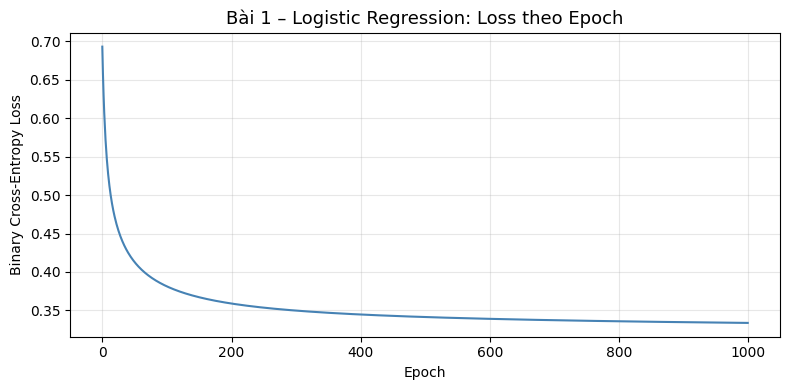

In [21]:
# Bước 4: Trực quan hóa quá trình huấn luyện (Loss Curve)

plt.figure(figsize=(8, 4))
plt.plot(model1.loss_history, color='steelblue', linewidth=1.5)
plt.title("Bài 1 – Logistic Regression: Loss theo Epoch", fontsize=13)
plt.xlabel("Epoch"); plt.ylabel("Binary Cross-Entropy Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Nhận xét đồ thị Loss bài 1

- **Xu hướng:** Loss giảm **nhanh và đều đặn** trong khoảng 200–300 epoch đầu, sau đó chậm dần và tiệm cận một giá trị ổn định.
- **Không dao động:** Đường loss mượt, không có hiện tượng tăng/giảm thất thường → learning rate `lr=0.1` phù hợp, không quá lớn.

KẾT QUẢ ĐÁNH GIÁ – Logistic Regression (NumPy)
Accuracy: 0.8249

Classification Report:
              precision    recall  f1-score   support

Non-Graduate       0.88      0.78      0.82       467
    Graduate       0.78      0.88      0.83       418

    accuracy                           0.82       885
   macro avg       0.83      0.83      0.82       885
weighted avg       0.83      0.82      0.82       885



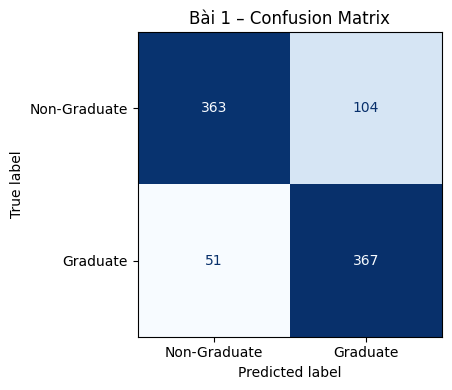

In [22]:
# Bước 5: Đánh giá mô hình

y1_pred = model1.predict(X1_test)

print("KẾT QUẢ ĐÁNH GIÁ – Logistic Regression (NumPy)")

print(f"Accuracy: {accuracy_score(y1_test, y1_pred):.4f}")
print()
print("Classification Report:")
print(classification_report(y1_test, y1_pred, target_names=['Non-Graduate', 'Graduate']))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(5, 4))
cm1 = confusion_matrix(y1_test, y1_pred)
disp1 = ConfusionMatrixDisplay(cm1, display_labels=['Non-Graduate', 'Graduate'])
disp1.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title("Bài 1 – Confusion Matrix", fontsize=12)
plt.tight_layout()
plt.show()

#### Nhận xét kết quả bài 1

- **Accuracy ≈ 82.5%:** Mô hình dự đoán đúng khoảng 82.5% mẫu trong tập test, kết quả tốt cho mô hình tuyến tính đơn giản.
- **Precision vs Recall:** Lớp `Non-Graduate` có **precision cao hơn** (0.88 vs 0.78) nghĩa là khi model dự đoán một sinh viên là Non-Graduate, nó đúng 88% trường hợp. Ngược lại, lớp `Graduate` có **recall cao hơn** (0.88 vs 0.78) model tìm được 88% số sinh viên tốt nghiệp thật sự. Điều này cho thấy model có xu hướng **dự đoán Graduate nhiều hơn thực tế** (thiên vị nhẹ về lớp majority).
- **F1-score cân bằng (0.82–0.83):** Cả 2 lớp đều có F1 gần nhau → model không bị lệch hẳn về một lớp nào.
- **Confusion Matrix:** False Positive và False Negative ở mức chấp nhận được với mô hình tuyến tính không có regularization.

### Assignment 2 (4 scores):

- Use Numpy only to construct the Sofmax Regression model.
- Train that Logistic Regression model dataset using the Gradient Descent approach on the [Predict students’ dropout and academic success](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success) dataset.
- Evaluate that Logistic Regression model on the [Predict students’ dropout and academic success](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success) dataset.
- Visualize the loss function of the training process.

In [23]:
# Bước 1: Tiền xử lý dữ liệu cho Bài 2 (Phân loại 3 lớp)

df2 = pd.read_csv('data.csv', sep=';')

# Giữ nguyên 3 nhãn, mã hóa sang số nguyên
df2['Target'] = df2['Target'].map({'Dropout': 0, 'Enrolled': 1, 'Graduate': 2})

X2 = df2.drop('Target', axis=1).values
y2 = df2['Target'].values

# Chia train/test (cùng random_state=42 để so sánh nhất quán)
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

# Tạo scaler riêng biệt cho Bài 2 (độc lập với Bài 1)
scaler2 = StandardScaler()
X2_train = scaler2.fit_transform(X2_train)
X2_test  = scaler2.transform(X2_test)

print(f"Tập train: {X2_train.shape}, Tập test: {X2_test.shape}")
count = np.bincount(y2_train)
print(f"Phân bố nhãn train: Dropout = {count[0]}, Enrolled = {count[1]}, Graduate = {count[2]}")

Tập train: (3539, 36), Tập test: (885, 36)
Phân bố nhãn train: Dropout = 1105, Enrolled = 643, Graduate = 1791


In [24]:
# Bước 2: Xây dựng lớp Softmax Regression bằng NumPy

class SoftmaxRegressionNumpy:
    def __init__(self, lr=0.1, epochs=1000):
        """
        lr     : learning rate
        epochs : số epoch huấn luyện
        """
        self.lr = lr
        self.epochs = epochs
        self.W = None          # Ma trận trọng số: (n_features, n_classes)
        self.B = None          # Bias vector: (n_classes,)
        self.loss_history = []

    def softmax(self, z):
        # Trừ max để ổn định số học (tránh exp overflow)
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        n_classes = len(np.unique(y))

        # One-hot encoding: chuyển nhãn nguyên sang vector 0/1
        Y_hot = np.eye(n_classes)[y]   # shape: (n_samples, n_classes)

        # Khởi tạo tham số
        self.W = np.zeros((n_features, n_classes))
        self.B = np.zeros(n_classes)

        for epoch in range(self.epochs):
            # --- Forward pass: tính xác suất từng lớp ---
            Z     = np.dot(X, self.W) + self.B   # (n_samples, n_classes)
            probs = self.softmax(Z)               # (n_samples, n_classes)

            # --- Gradient (Categorical Cross-Entropy + Softmax kết hợp) ---
            diff = probs - Y_hot                  # (n_samples, n_classes)
            dW   = (1 / n_samples) * np.dot(X.T, diff)       # (n_features, n_classes)
            dB   = (1 / n_samples) * np.sum(diff, axis=0)    # (n_classes,)

            # --- Cập nhật tham số ---
            self.W -= self.lr * dW
            self.B -= self.lr * dB

            # --- Categorical Cross-Entropy Loss ---
            loss = -np.mean(np.sum(Y_hot * np.log(probs + 1e-15), axis=1))
            self.loss_history.append(loss)

    def predict_proba(self, X):
        return self.softmax(np.dot(X, self.W) + self.B)

    def predict(self, X):
        # Chọn lớp có xác suất cao nhất
        return np.argmax(self.predict_proba(X), axis=1)

print("Định nghĩa lớp SoftmaxRegressionNumpy hoàn tất.")

Định nghĩa lớp SoftmaxRegressionNumpy hoàn tất.


In [25]:
# Bước 3: Huấn luyện mô hình

model2 = SoftmaxRegressionNumpy(lr=0.1, epochs=1000)
model2.fit(X2_train, y2_train)

print(f"Loss ban đầu (epoch 1)  : {model2.loss_history[0]:.4f}")
print(f"Loss cuối (epoch 1000)  : {model2.loss_history[-1]:.4f}")
print(f"Loss giảm               : {model2.loss_history[0] - model2.loss_history[-1]:.4f}")

Loss ban đầu (epoch 1)  : 1.0986
Loss cuối (epoch 1000)  : 0.5526
Loss giảm               : 0.5460


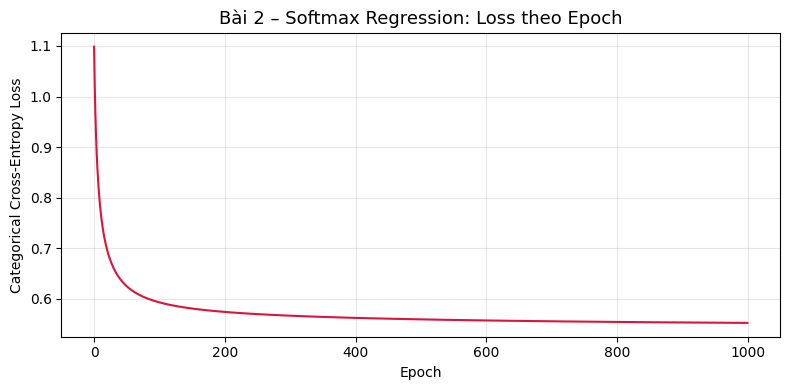

In [26]:
# Bước 4: Trực quan hóa Loss Curve

plt.figure(figsize=(8, 4))
plt.plot(model2.loss_history, color='crimson', linewidth=1.5)
plt.title("Bài 2 – Softmax Regression: Loss theo Epoch", fontsize=13)
plt.xlabel("Epoch"); plt.ylabel("Categorical Cross-Entropy Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Nhận xét đồ thị Loss - Bài 2

- **Xu hướng:** Loss giảm đều, tương tự Bài 1, và hội tụ sau khoảng 500–700 epoch.
- **Giá trị loss cao hơn Bài 1:** Điều này là **bình thường** — Categorical Cross-Entropy trên 3 lớp có giá trị lớn hơn Binary Cross-Entropy trên 2 lớp vì tổng nhiều số hạng hơn.
- **Không dao động:** Đường loss mượt → learning rate `lr=0.1` phù hợp cho bài toán 3 lớp.
- **Bài toán khó hơn Bài 1:** 3 lớp thay vì 2 lớp, đặc biệt lớp `Enrolled` khó phân biệt với 2 lớp còn lại (sinh viên đang học có thể sau đó tốt nghiệp hoặc bỏ học).

KẾT QUẢ ĐÁNH GIÁ – Softmax Regression (NumPy)
Accuracy: 0.7503

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.84      0.77      0.80       316
    Enrolled       0.43      0.25      0.32       151
    Graduate       0.76      0.92      0.83       418

    accuracy                           0.75       885
   macro avg       0.67      0.65      0.65       885
weighted avg       0.73      0.75      0.73       885



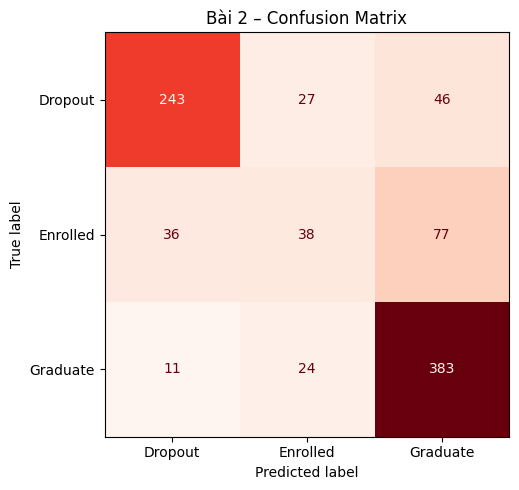

In [27]:
# Bước 5: Đánh giá mô hình

y2_pred = model2.predict(X2_test)

print("KẾT QUẢ ĐÁNH GIÁ – Softmax Regression (NumPy)")

print(f"Accuracy: {accuracy_score(y2_test, y2_pred):.4f}")
print()
print("Classification Report:")
print(classification_report(
    y2_test, y2_pred,
    target_names=['Dropout', 'Enrolled', 'Graduate']
))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm2 = confusion_matrix(y2_test, y2_pred)
disp2 = ConfusionMatrixDisplay(cm2, display_labels=['Dropout', 'Enrolled', 'Graduate'])
disp2.plot(ax=ax, colorbar=False, cmap='Reds')
ax.set_title("Bài 2 – Confusion Matrix", fontsize=12)
plt.tight_layout()
plt.show()

### Assignment 3 (2 scores):

- Use a Machine Learning library (Scikit Learn or Skorch) to implement and evaluate the Logistic Regression on the [Predict students’ dropout and academic success](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success) dataset.
- Use a Machine Learning library (Scikit Learn or Skorch) to implement and evaluate the Softmax Regression on the [Predict students’ dropout and academic success](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success) dataset.

In [28]:
from sklearn.linear_model import LogisticRegression

# 3.1 Logistic Regression (sklearn) – Dùng dữ liệu của Bài 1

lib_model1 = LogisticRegression(max_iter=1000, random_state=42)
lib_model1.fit(X1_train, y1_train)
y1_pred_lib = lib_model1.predict(X1_test)

print("3.1 Logistic Regression (Sklearn)")

print(f"Accuracy: {accuracy_score(y1_test, y1_pred_lib):.4f}")
print()
print(classification_report(y1_test, y1_pred_lib, target_names=['Non-Graduate', 'Graduate']))

3.1 Logistic Regression (Sklearn)
Accuracy: 0.8282

              precision    recall  f1-score   support

Non-Graduate       0.88      0.78      0.83       467
    Graduate       0.78      0.88      0.83       418

    accuracy                           0.83       885
   macro avg       0.83      0.83      0.83       885
weighted avg       0.83      0.83      0.83       885



In [29]:
# 3.2 Softmax Regression (sklearn) – Dùng dữ liệu của Bài 2

lib_model2 = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
lib_model2.fit(X2_train, y2_train)
y2_pred_lib = lib_model2.predict(X2_test)

print("3.2 Softmax Regression (Sklearn)")

print(f"Accuracy: {accuracy_score(y2_test, y2_pred_lib):.4f}")
print()
print(classification_report(y2_test, y2_pred_lib, target_names=['Dropout', 'Enrolled', 'Graduate']))

3.2 Softmax Regression (Sklearn)
Accuracy: 0.7525

              precision    recall  f1-score   support

     Dropout       0.83      0.77      0.80       316
    Enrolled       0.45      0.28      0.34       151
    Graduate       0.76      0.91      0.83       418

    accuracy                           0.75       885
   macro avg       0.68      0.65      0.66       885
weighted avg       0.73      0.75      0.74       885



                      Mô hình           Bài toán Accuracy
  Logistic Regression (NumPy)     Binary (2 lớp)   0.8249
Logistic Regression (Sklearn)     Binary (2 lớp)   0.8282
   Softmax Regression (NumPy) Multiclass (3 lớp)   0.7503
 Softmax Regression (Sklearn) Multiclass (3 lớp)   0.7525


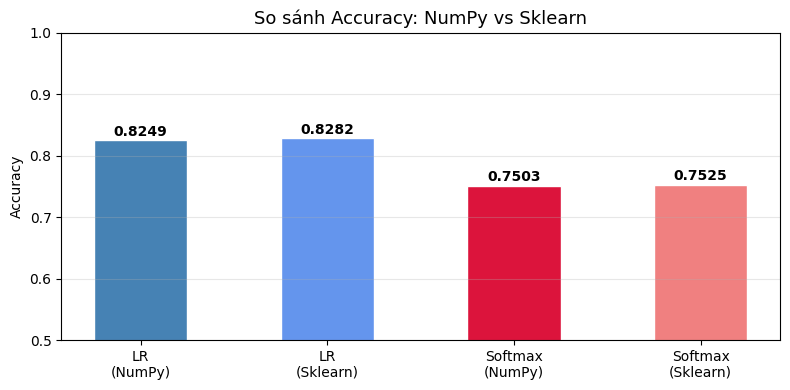

In [30]:
# Bảng tổng hợp kết quả

results = {
    'Mô hình': [
        'Logistic Regression (NumPy)',
        'Logistic Regression (Sklearn)',
        'Softmax Regression (NumPy)',
        'Softmax Regression (Sklearn)'
    ],
    'Bài toán': ['Binary (2 lớp)', 'Binary (2 lớp)', 'Multiclass (3 lớp)', 'Multiclass (3 lớp)'],
    'Accuracy': [
        accuracy_score(y1_test, y1_pred),
        accuracy_score(y1_test, y1_pred_lib),
        accuracy_score(y2_test, y2_pred),
        accuracy_score(y2_test, y2_pred_lib)
    ]
}

df_results = pd.DataFrame(results)
df_results['Accuracy'] = df_results['Accuracy'].map('{:.4f}'.format)
print(df_results.to_string(index=False))

# Biểu đồ so sánh
acc_values = [
    accuracy_score(y1_test, y1_pred),
    accuracy_score(y1_test, y1_pred_lib),
    accuracy_score(y2_test, y2_pred),
    accuracy_score(y2_test, y2_pred_lib)
]
labels = ['LR\n(NumPy)', 'LR\n(Sklearn)', 'Softmax\n(NumPy)', 'Softmax\n(Sklearn)']
colors = ['steelblue', 'cornflowerblue', 'crimson', 'lightcoral']

plt.figure(figsize=(8, 4))
bars = plt.bar(labels, acc_values, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, acc_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.ylim(0.5, 1.0)
plt.title("So sánh Accuracy: NumPy vs Sklearn", fontsize=13)
plt.ylabel("Accuracy")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#### Nhận xét tổng kết

**1. NumPy vs Sklearn có kết quả xấp xỉ nhau:**

| Mô hình | NumPy | Sklearn | Chênh lệch |
|---------|-------|---------|------------|
| Logistic Regression | 0.8249 | 0.8282 | +0.0033 |
| Softmax Regression | 0.7503 | 0.7525 | +0.0022 |

**2. Binary (Bài 1) vs Multiclass (Bài 2)**

Accuracy Bài 1 (~82.5%) > Bài 2 (~75%) vì:
- Bài 1 chỉ cần vẽ **1 đường ranh giới** phân tách 2 lớp
- Bài 2 cần vẽ **3 đường ranh giới** đồng thời, đặc biệt lớp `Enrolled` (F1=0.32) **chồng lấp đặc trưng** với cả Dropout lẫn Graduate
- Lớp `Enrolled` chỉ có 794 mẫu (ít nhất) → model không học đủ pattern để phân biệt